Shape of the dataset: (22, 4)

Column names:
 Index(['Car Model', 'Mileage', 'Sell Price', 'Age'], dtype='object')

Data types:
 Car Model     object
Mileage        int64
Sell Price     int64
Age            int64
dtype: object

First five rows:
   Car Model  Mileage  Sell Price  Age
0      Audi    87000       76543    2
1      Audi    67000       58760    3
2      Audi    45000       27650    4
3    BMW X5    78000       66540    7
4    BMW X5    67000       56450    1

Statistical summary:
             Mileage    Sell Price        Age
count     22.000000     22.000000  22.000000
mean   71679.090909  61045.636364   4.227273
std    18343.349881  18119.575133   2.599117
min    23000.000000  13650.000000   1.000000
25%    65577.500000  54567.500000   2.250000
50%    76365.000000  65818.000000   3.500000
75%    87000.000000  76375.000000   5.750000
max    98600.000000  87670.000000   9.000000

Missing values:
 Car Model     0
Mileage       0
Sell Price    0
Age           0
dtype: int64


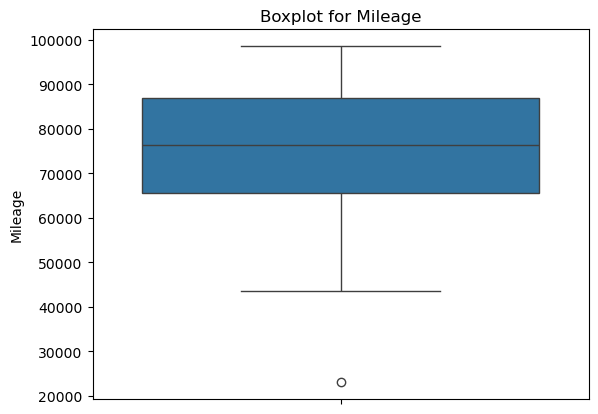

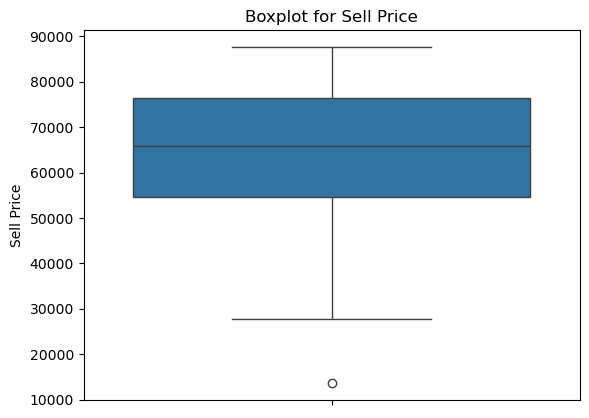

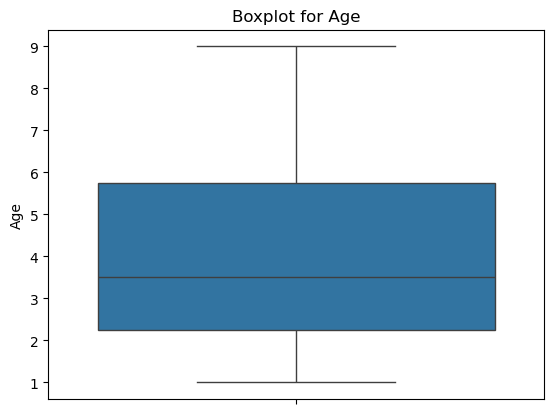

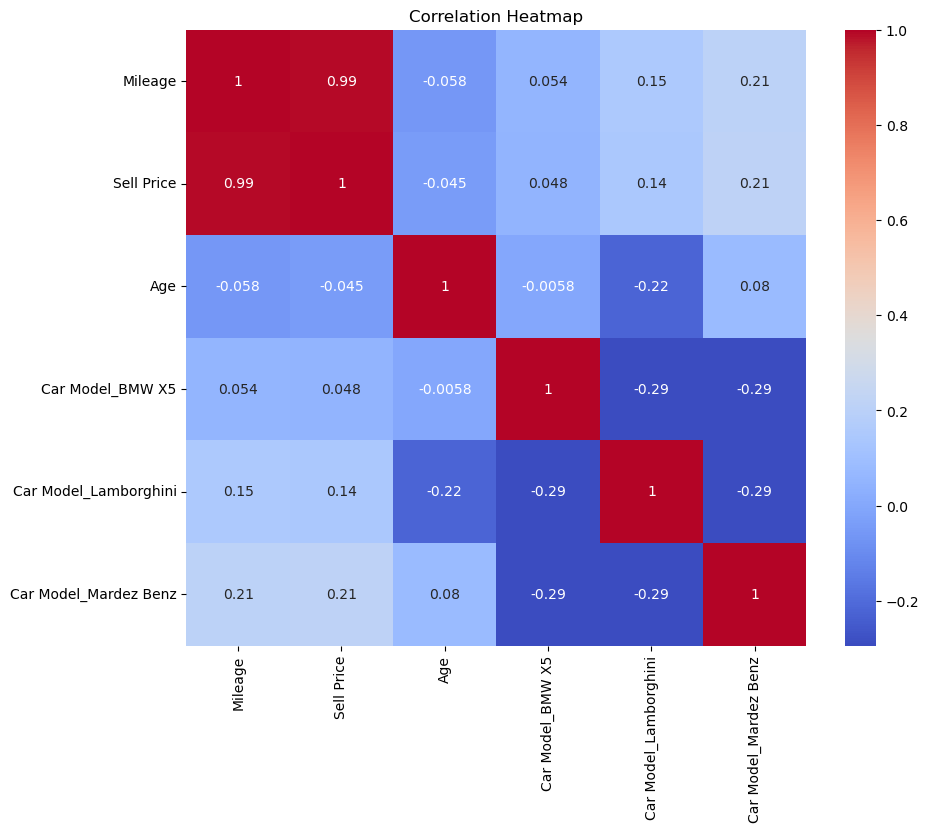

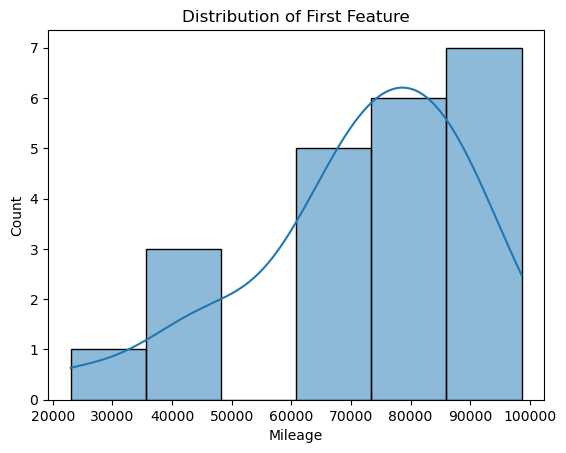

<Figure size 640x480 with 0 Axes>

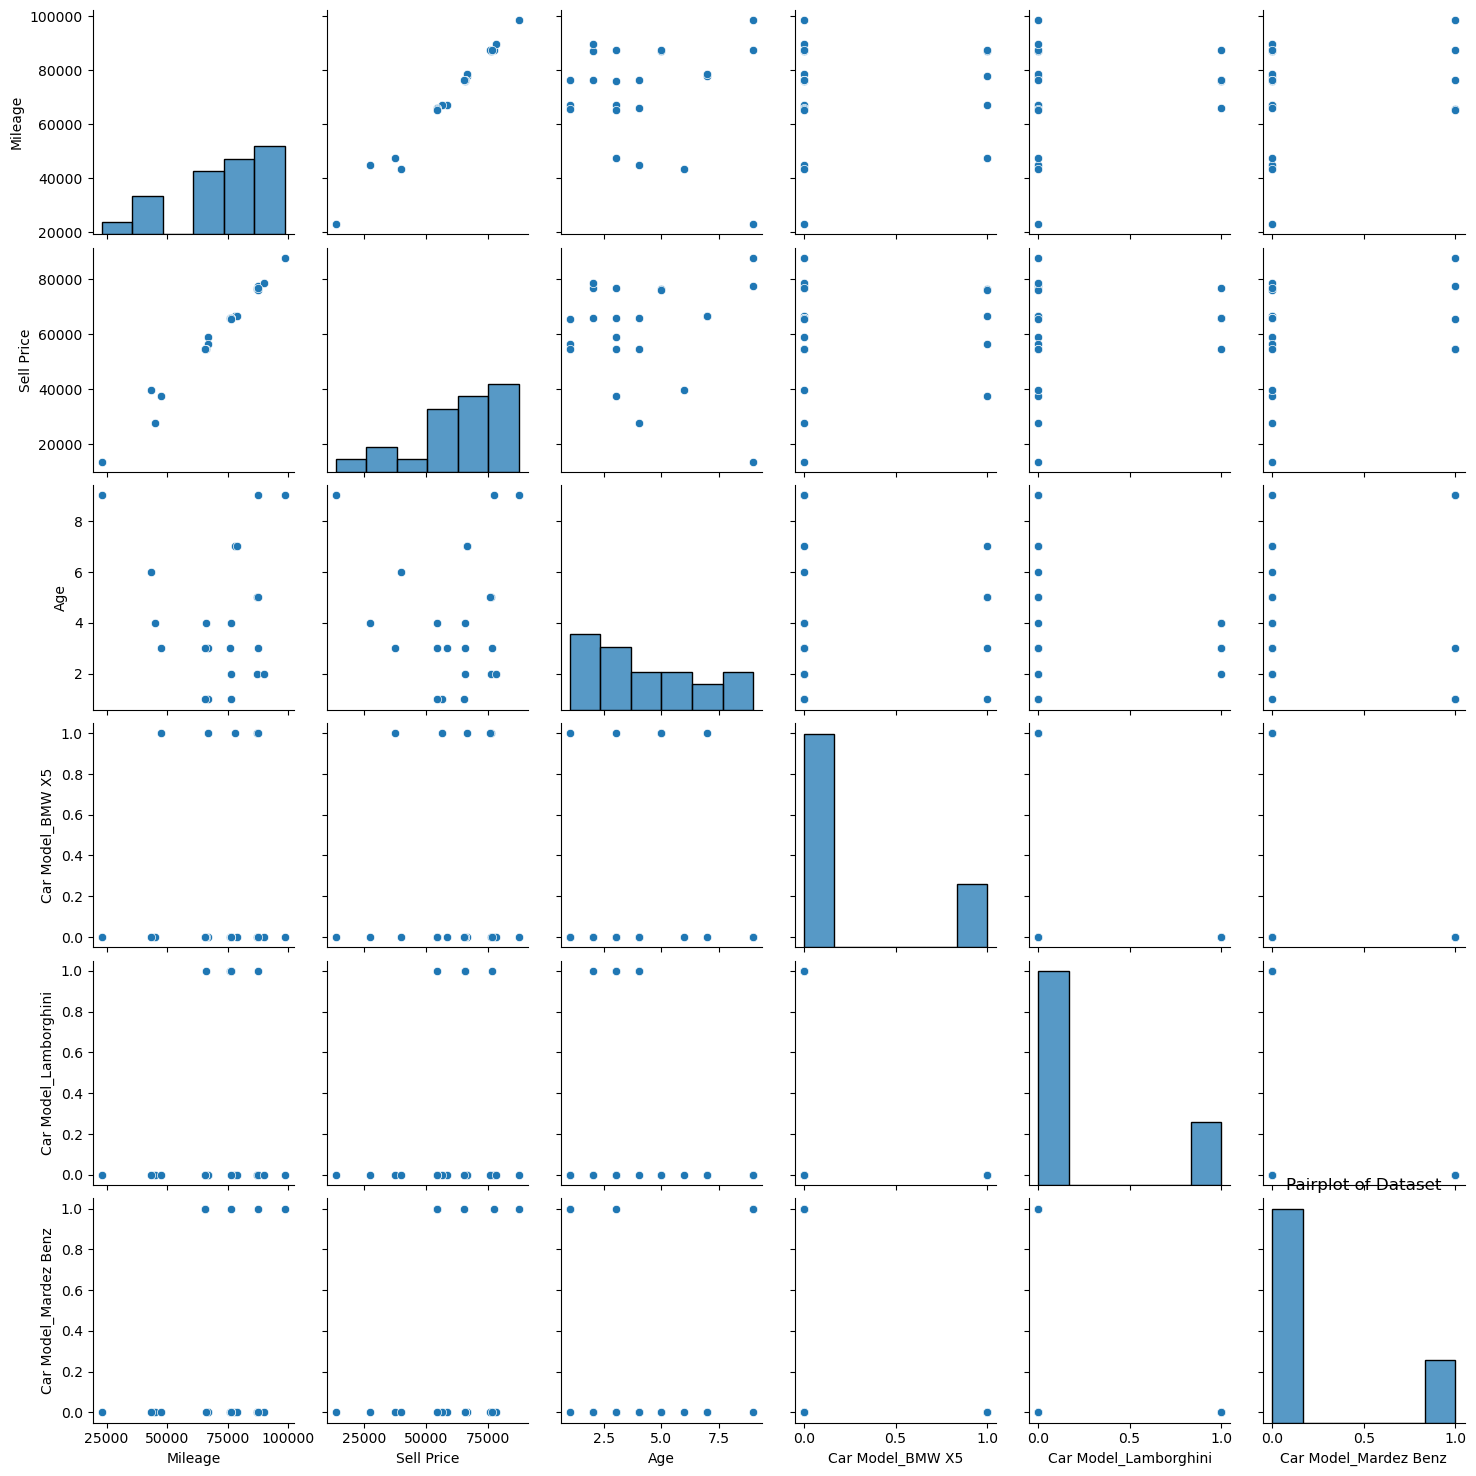


EDA Completed Successfully!


In [1]:
# Exploratory Data Analysis (EDA)

# 1. Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 2. Load the dataset
data = pd.read_csv("datasets/car.csv")

# 3. Basic information about data
print("Shape of the dataset:", data.shape)
print("\nColumn names:\n", data.columns)
print("\nData types:\n", data.dtypes)
print("\nFirst five rows:\n", data.head())
print("\nStatistical summary:\n", data.describe())
print("\nMissing values:\n", data.isnull().sum())

# 4. Handle missing values (example)
data.fillna(data.mean(numeric_only=True), inplace=True)

# 5. Remove duplicates
data.drop_duplicates(inplace=True)

# 6. Detect outliers using boxplot
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure()
    sns.boxplot(data[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

# 7. Encode categorical columns using get_dummies
data = pd.get_dummies(data, drop_first=True)

# 8. Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 9. Visualization examples
plt.figure()
sns.histplot(data.iloc[:,0], kde=True)
plt.title("Distribution of First Feature")
plt.show()

plt.figure()
sns.pairplot(data)
plt.title("Pairplot of Dataset")
plt.show()

# 10. Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.select_dtypes(include=['float64', 'int64']))
scaled_df = pd.DataFrame(scaled_data, columns=data.select_dtypes(include=['float64', 'int64']).columns)

# 11. Splitting data into train and test sets
X = data.drop('target', axis=1, errors='ignore')  # replace 'target' with your target column
y = data['target'] if 'target' in data.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("\nTraining set size:", X_train.shape)
    print("Testing set size:", X_test.shape)

# 12. Summary
print("\nEDA Completed Successfully!")
